### 加载数据

In [128]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio import Population,MultiPeriodPortfolio
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
from log_result import init_logger, log_result, log_print
set_config(transform_output="pandas")
init_logger("WF_CPCV_PS_126")      # 只调用一次, 绑定文件名
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 关键: 负号才不会变方块

[log] 已绑定: D:\machine-learning-for-trading\case_studies\lazy_trading\logs\WF_CPCV_PS_126.log


In [129]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 参数搜索
- Walkforward:
    - CombinatorialPurgedCV

In [130]:
from wf_cpcv_search import load_nested_config
from cpcv_search_base import build_pipeline_src
from walkforward_parameter_search import compute_grid_size
from wf_cpcv_search import nested_adaptive_search, adaptive_multi_paths, build_test_parts, summarize_fold_params,summarize_top_k_params
from cpcv_analysis import discrete_lhs_safe, diagnose_oos_lhs, report_ann_distribution, turnover_series
from cpcv_analysis import plot_oos_vs_bench,excess_vs_bench, plot_paths_curve
from wf_cpcv_robustness import (perturbation_mc, sensitivity_curves, sensitivity_heatmap, topk_paths_eval,)
from wf_cpcv_ablation import ablate

In [131]:
log_print("mean(Annualized Sharpe Ratio)/2 - mean(MAXDD) + mean(SKEW)", section='Ojective', echo=False)
log_print(build_pipeline_src(), section="Model Pipeline", echo=False)

In [132]:
search_space = {'nondomin__min_n_assets': {'low': 5, 'high': 55, 'step': 5},
 'nondomin__threshold': {'low': -0.5, 'high': -0.3, 'step': 0.1},
 'correlate__threshold': {'low': 0.1, 'high': 0.5, 'step': 0.1},
 'extremes__k': {'low': 0.1, 'high': 0.6, 'step': 0.1},
 'nondomin__fitness_measures': [
    "mean-variance-kurt",
    "mean-variance-maxdd-kurt",
    "mean-variance-avgdd-kurt",
    "mean-semideviation-avgdd",
    "mean-mad-maxdd-kurt",
    "mean-mad-avgdd-kurt",
    "mean-mad-maxdd-cvar-kurt",
    "mean-mad-maxdd-cvar-sharpe",
    "mean-mad-avgdd-cvar-kurt",
    "mean-mad-avgdd-cvar-sharpe",
    ],
 'train_size': {'low': 252, 'high': 756, 'step': 126}}  # inner train size
log_print(search_space, section='Parameter Space', echo=False)
compute_grid_size(search_space)

49500

In [133]:
search_params = {'test_size': 126,
  'train_size': 756+126,
  'n_test_folds': 2,
  'n_jobs': 4,
  'cv_n_jobs': 8,
  'n_trials': 2000,
  'patience': 50,
  'sampler': 'tpe',
  'min_delta': 0.0001,
  'outer_purged_size': 1,
  'outer_reduce_test': False,
  'seed': 42,
  'verbose': True}
log_print(search_params, section="Search Parameter", echo=False)

In [134]:
fold_results = nested_adaptive_search(X,space=search_space, **search_params)

  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 0: mean score=0.8437 | test_ann=0.2668 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 1: mean score=1.1423 | test_ann=0.1617 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

...

Fold 10: mean score=2.1171 | test_ann=0.0991 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 11: mean score=0.6490 | test_ann=0.4124 | test_days=126


  0%|          | 0/2000 [00:00<?, ?it/s]

Fold 12: mean score=1.3011 | test_ann=-0.0662 | test_days=126


### Step 1 | IS 审计：每折 DSR + Top-K 候选
- dsr = 该折最优分数超过"纯运气挑最优"基准的经验概率（H0 噪声 MC deflate，N = 参数去重后的真实试验数）。 margin = sr_obs − E[max_N]，max_p95 为运气基准 95% 分位。
- gap2top1（summarize_top_k_params 的列）= IS 侧 top1 与 top2 的分数落差： 落差小 → 参数处在平台（好信号）；落差大 → top1 可能是运气孤峰（坏信号）。

In [135]:
log_print(summarize_fold_params(fold_results).to_string(),section='Best Parameter', echo=True)

    fold   score     dsr  sr_obs  margin  train ASR  test ASR  nondomin__min_n_assets  nondomin__threshold  correlate__threshold  extremes__k  train_size                     fitness  n_trials
0      0  0.8437  0.0314  0.8437 -0.3559     1.1187    3.0007                      40                 -0.5                   0.1          0.6         252    mean-mad-avgdd-cvar-kurt        71
1      1  1.1423  0.5008  1.1423 -0.0214     1.7564    2.2174                      50                 -0.5                   0.2          0.6         252  mean-mad-maxdd-cvar-sharpe        72
2      2  0.7761  0.5345  0.7761 -0.0032     1.5136   -0.4304                      35                 -0.4                   0.2          0.5         378  mean-mad-avgdd-cvar-sharpe        88
3      3  0.7168  0.3257  0.7168 -0.0752     1.4198    2.7916                      15                 -0.5                   0.2          0.5         504    mean-semideviation-avgdd        78
4      4  1.6075  0.9640  1.6075  0.4399

In [136]:
topk = summarize_top_k_params(fold_results, k=5)         # 行 = (fold, rank)
print(topk[topk["rank"] <= 3][['fold','rank','score','gap2top1']])                    # 每折 top1/top2 候选 + gap2top1

    fold  rank   score  gap2top1
0      0     1  0.8437    0.0000
1      0     2  0.7726    0.0711
2      0     3  0.7726    0.0711
5      1     1  1.1423    0.0000
6      1     2  1.1340    0.0084
7      1     3  1.1335    0.0088
10     2     1  0.7761    0.0000
11     2     2  0.7329    0.0431
12     2     3  0.7128    0.0633
15     3     1  0.7168    0.0000
16     3     2  0.7017    0.0151
17     3     3  0.7017    0.0151
20     4     1  1.6075    0.0000
21     4     2  1.5342    0.0733
22     4     3  1.5103    0.0972
25     5     1  0.7407    0.0000
26     5     2  0.7381    0.0026
27     5     3  0.6996    0.0411
30     6     1  0.5820    0.0000
31     6     2  0.5451    0.0369
32     6     3  0.5388    0.0432
35     7     1  0.6260    0.0000
36     7     2  0.6260    0.0000
37     7     3  0.6143    0.0117
40     8     1  0.5898    0.0000
41     8     2  0.5856    0.0042
42     8     3  0.5781    0.0117
45     9     1  1.1743    0.0000
46     9     2  1.1743    0.0000
47     9  

### Step 2｜过拟合判据：DSR 低 + OOS 衰减
- 判据：WFE > 0.5 为稳健泛化（多数折满足）。
- "DSR 低 + OOS 显著下降" = 内层选择偏差校正后无真实优势 + 样本外掉队 → 该折结论不可信，

In [137]:
df = summarize_fold_params(fold_results).copy()
df["WFE"] = df["test ASR"] / df["train ASR"]      # 每折 IS→OOS 衰减比
df["flag"] = (df["dsr"] < 0.5) & (df["WFE"] < 0.5)   # 双低 = 过拟合嫌疑折
print(df[["fold", "dsr", "train ASR", "test ASR", "WFE", "flag"]])

    fold     dsr  train ASR  test ASR       WFE   flag
0      0  0.0314     1.1187    3.0007  2.682310  False
1      1  0.5008     1.7564    2.2174  1.262469  False
2      2  0.5345     1.5136   -0.4304 -0.284355  False
3      3  0.3257     1.4198    2.7916  1.966192  False
4      4  0.9640     0.8568    2.1501  2.509454  False
5      5  0.4139     1.6787    0.2044  0.121761   True
6      6  0.0724     1.0104    0.9611  0.951207  False
7      7  0.1511     0.4841    1.2212  2.522619  False
8      8  0.1242     1.1674    2.2076  1.891040  False
9      9  0.4896     1.2722    0.4347  0.341692   True
10    10  0.9710     1.2076    0.8599  0.712074  False
11    11  0.0661     0.9446    3.0448  3.223375  False
12    12  0.2977     1.0648   -1.0700 -1.004884   True


### Step 3｜Top-K 候选 OOS 多路径压测
- 窗口自动从 folds 推导（折位 1:1）；如需 notebook 原压测口径（如 `n_test_folds=4`），
  以显式键传入：`topk_paths_eval(X, folds, paths_kwargs={"n_test_folds": 4})`。
- 价值在**参数高原的 OOS 侧印证**：gap2top1 小的候选若 OOS 同样接近，说明生产参数处在稳定平台。

In [138]:
eval_ = topk_paths_eval(X, fold_results, k=10)            # 每折 top1~5 全部进 CPCV 多路径压测

rank1: 完整OOS路径 | 13 折拼接 | 1638 天
rank2: 完整OOS路径 | 13 折拼接 | 1638 天
rank3: 完整OOS路径 | 13 折拼接 | 1638 天
rank4: 完整OOS路径 | 13 折拼接 | 1638 天
rank5: 完整OOS路径 | 13 折拼接 | 1638 天
rank6: 完整OOS路径 | 13 折拼接 | 1638 天
rank7: 完整OOS路径 | 13 折拼接 | 1638 天
rank8: 完整OOS路径 | 13 折拼接 | 1638 天
rank9: 完整OOS路径 | 13 折拼接 | 1638 天
rank10: 完整OOS路径 | 13 折拼接 | 1638 天


In [ ]:

paths = eval_["paths"]                            # MultiIndex (fold, rank, path)
audit = eval_["audit"]                            # IS 侧审计，与 paths 按 (fold, rank) 对齐
sharpe = paths["annualized_sharpe_ratio"].groupby("rank").mean()
print(sharpe)              # rank 均值对比（不选参，只看高原）

rank
1     1.351959
2     1.075185
3     0.994801
4     1.082104
5     1.261728
6     1.279105
7     1.276175
8     1.063306
9     0.684915
10    1.105932
Name: annualized_sharpe_ratio, dtype: float64


In [ ]:
log_print(paths, section="Top 10 参数组合OOS:ASR,MEAN,MAXDD")

      annualized_sharpe_ratio  annualized_mean  max_drawdown
rank                                                        
1                    1.351959         0.126786      0.106783
2                    1.075185         0.094841      0.106783
3                    0.994801         0.079243      0.097372
4                    1.082104         0.086211      0.084887
5                    1.261728         0.104437      0.089624
6                    1.279105         0.118144      0.106783
7                    1.276175         0.112753      0.107089
8                    1.063306         0.092045      0.106783
9                    0.684915         0.060083      0.188325
10                   1.105932         0.098770      0.123833


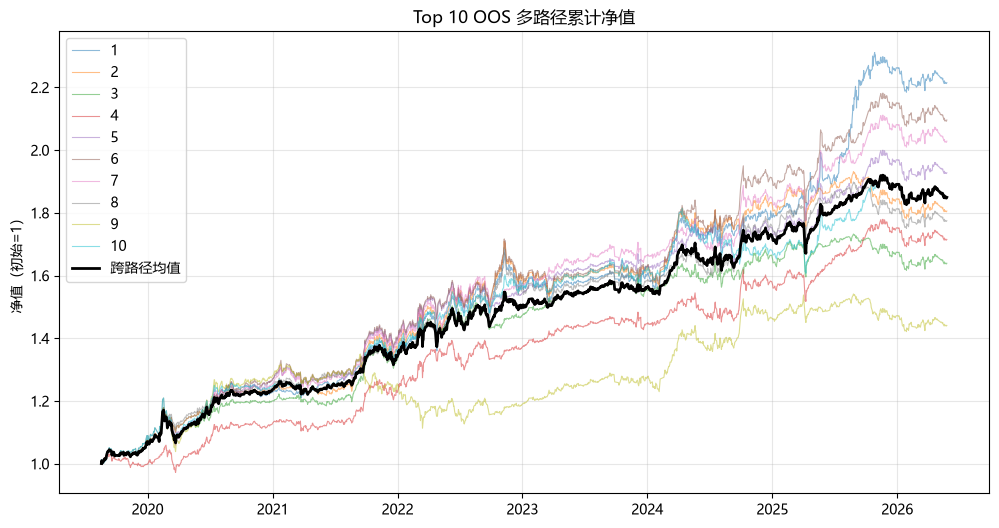

In [143]:
top_k_mpts = Population([mpt for mpt in eval_['mpts'].values()])
plot_paths_curve(top_k_mpts, title='Top 10 OOS 多路径累计净值', labels=[k for k in eval_['mpts'].keys()])

### Step 4｜单参数敏感性曲线
- 每折只动目标参数、其余保持生产值（fitness 固定 top1）；`frac=0` 档即生产值本身（锚点）。
- 默认覆盖**全部数值参数含 `train_size`**（它是搜索维度之一，扰动后评估即用扰动后的拟合窗口长度）。
- 读图：参数高原 = ±30% 内绩效平缓；孤峰 = 仅生产值附近突出（与 IS 侧 gap2top1 互证）。
- 只评估单折 OOS → 无 CPCV 展开，成本低，可全参数全档位跑。

In [144]:
curves = sensitivity_curves(X, fold_results, reduce_test=False)             # 默认 ±10/20/30% 六档 × 全部数值参数
c = curves[curves["param"] == "extremes__k"]
ax = c.pivot_table(index="frac", columns="fold",
                   values="annualized_sharpe_ratio").plot(marker="o")

Fold 0: 单参网格完成 (5 参数 × 6 档)
Fold 1: 单参网格完成 (5 参数 × 6 档)
Fold 2: 单参网格完成 (5 参数 × 6 档)
Fold 3: 单参网格完成 (5 参数 × 6 档)
Fold 4: 单参网格完成 (5 参数 × 6 档)
Fold 5: 单参网格完成 (5 参数 × 6 档)
Fold 6: 单参网格完成 (5 参数 × 6 档)
Fold 7: 单参网格完成 (5 参数 × 6 档)
Fold 8: 单参网格完成 (5 参数 × 6 档)
Fold 9: 单参网格完成 (5 参数 × 6 档)
Fold 10: 单参网格完成 (5 参数 × 6 档)
Fold 11: 单参网格完成 (5 参数 × 6 档)
Fold 12: 单参网格完成 (5 参数 × 6 档)


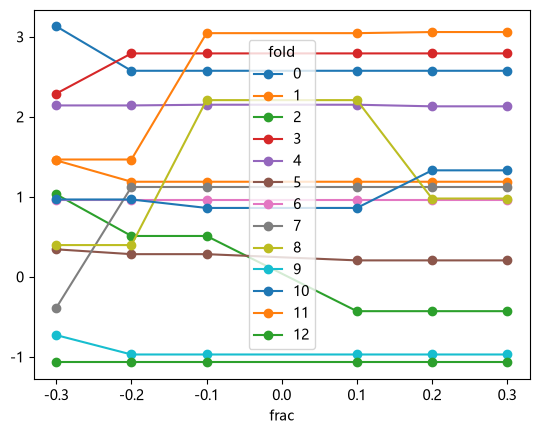

In [145]:
plt.show()

### Step 5｜双参数联合热力图（checklist 4.2）

- 返回 `{fold: DataFrame(index=frac_a, columns=frac_b), "mean": 跨折逐格平均}`。
- 读图：各档平缓 → 联合高原（稳健）；仅 (0,0) 突出 → 联合孤峰（脆弱）；
  对角陡峭 → 两参数互补/冲突（交互项存在）。

Fold 0: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 1: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 2: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 3: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 4: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 5: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 6: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 7: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 8: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 9: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 10: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 11: extremes__k×correlate__threshold 热力图 (5×5) 完成
Fold 12: extremes__k×correlate__threshold 热力图 (5×5) 完成


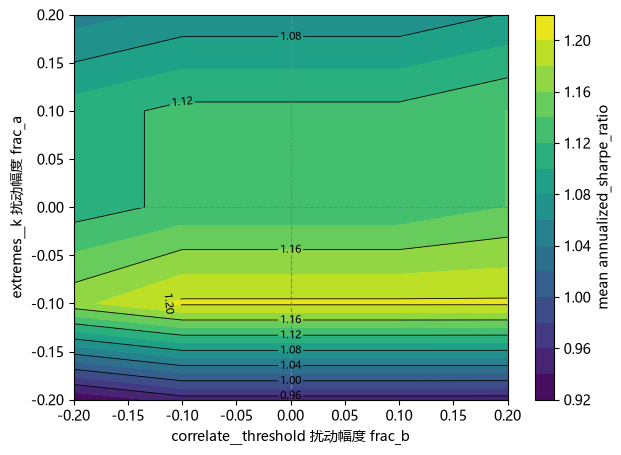

In [146]:
import numpy as np
import matplotlib.pyplot as plt

grids = sensitivity_heatmap(X, fold_results, param_a="extremes__k",
                            param_b="correlate__threshold",
                            reduce_test=False)
mean = grids["mean"]                          # 行=frac_a, 列=frac_b, 值=跨折平均ASR
Xg, Yg = np.meshgrid(mean.columns, mean.index)   # x=frac_b, y=frac_a，与 values[i,j] 对齐
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(Xg, Yg, mean.values, levels=15, cmap="viridis")   # 彩色填充
cs = ax.contour(Xg, Yg, mean.values, levels=8, colors="k", linewidths=0.6)  # 等值线
ax.clabel(cs, inline=True, fontsize=8)        # 标数值
ax.axhline(0, color="gray", lw=0.8, ls="--")  # 生产值锚点十字线（0,0 = 未扰动）
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("correlate__threshold 扰动幅度 frac_b")
ax.set_ylabel("extremes__k 扰动幅度 frac_a")
fig.colorbar(cf, label="mean annualized_sharpe_ratio")
plt.show()

### Step 6｜消融实验

- 臂：`full`（基准）/ `no_extremes` / `no_nondomin` / `no_correlate` / `no_extremes_correlate`。
- 每臂 = 固定每折最优参数 × 剔除对应管线步骤 × CPCV 多路径压测（同窗同口径对比）。
- 判读：全臂样本路径数一致（每折 = `n_test_folds` 组合路径），绩效差距即模块边际贡献；
  某模块剔除后绩效**不降反升** → 该模块负贡献，考虑剔除后重搜（会作废旧 OOS）。

In [147]:
frames, summary = ablate(X, fold_results)                # arms=None = 全部 5 臂
summary

,说明,折数,天数,annualized_mean,annualized_sharpe_ratio,max_drawdown,skew,kurtosis
臂,,,,,,,,
full,全管线（基准）,13,1638,0.126786,1.351959,0.106783,-0.168806,8.971582
no_extremes,无峰度预筛（剔除 extremes 步骤）,13,1638,0.070502,1.136836,0.081673,-0.249752,12.785712
no_nondomin,无非支配筛选（剔除 nondomin 步骤）,13,1638,0.113074,1.195543,0.096342,-0.588667,9.059370
no_correlate,无去相关（剔除 correlate 步骤）,13,1638,0.089402,0.691065,0.295571,-0.217578,11.506234
no_extremes_correlate,剔除 extremes + correlate,13,1638,0.091271,0.898612,0.207247,0.029218,11.758804


In [148]:
log_result(summary.to_string(), section="消融实验")

### Step 7｜参数扰动蒙特卡洛 + 判定

In [149]:
out = perturbation_mc(X, fold_results, fitness_topk=5)                   # R=None → ceil(500 / 折数)，总样本 ≥ 500

Fold 0: R=39 | fitness池=['mean-mad-avgdd-cvar-kurt', 'mean-mad-avgdd-kurt', 'mean-mad-maxdd-cvar-kurt', 'mean-mad-maxdd-kurt', 'mean-variance-avgdd-kurt'] | 扰动脉冲完成（39 组 × 普通OOS单测）
Fold 1: R=39 | fitness池=['mean-mad-maxdd-cvar-sharpe', 'mean-semideviation-avgdd', 'mean-mad-avgdd-cvar-sharpe', 'mean-mad-avgdd-cvar-kurt', 'mean-variance-avgdd-kurt'] | 扰动脉冲完成（39 组 × 普通OOS单测）
Fold 2: R=39 | fitness池=['mean-mad-avgdd-cvar-sharpe', 'mean-semideviation-avgdd', 'mean-mad-avgdd-cvar-kurt', 'mean-mad-maxdd-cvar-sharpe', 'mean-variance-avgdd-kurt'] | 扰动脉冲完成（39 组 × 普通OOS单测）
Fold 3: R=39 | fitness池=['mean-semideviation-avgdd', 'mean-mad-avgdd-cvar-kurt', 'mean-mad-avgdd-cvar-sharpe', 'mean-mad-avgdd-kurt', 'mean-mad-maxdd-cvar-sharpe'] | 扰动脉冲完成（39 组 × 普通OOS单测）
Fold 4: R=39 | fitness池=['mean-variance-maxdd-kurt', 'mean-mad-avgdd-cvar-kurt', 'mean-variance-avgdd-kurt', 'mean-mad-avgdd-kurt', 'mean-mad-maxdd-cvar-sharpe'] | 扰动脉冲完成（39 组 × 普通OOS单测）
Fold 5: R=39 | fitness池=['mean-semideviation-avgdd', 'me

In [150]:
out['verdict']

,指标,样本数,prob>0,median,p95,通过
0,annualized_mean,507,0.903353,0.113004,0.316511,True
1,annualized_sharpe_ratio,507,0.903353,1.261678,3.139579,True


In [151]:
out['fold_summary']

,n,annualized_mean_mean,annualized_mean_median,annualized_mean_p5,annualized_mean_p95,annualized_sharpe_ratio_mean,annualized_sharpe_ratio_median,annualized_sharpe_ratio_p5,annualized_sharpe_ratio_p95,max_drawdown_mean,...,max_drawdown_p95,skew_mean,skew_median,skew_p5,skew_p95,kurtosis_mean,kurtosis_median,kurtosis_p5,kurtosis_p95,pos_prob
fold,,,,,,,,,,,,,,,,,,,,,
0,39,0.114112,0.052112,0.017740,0.396740,1.292467,1.046858,0.295861,3.139579,0.036794,...,0.054353,0.035468,0.242569,-0.726920,0.553630,6.161362,6.350444,5.386924,6.641066,1.000000
1,39,0.195789,0.211091,0.090474,0.288069,1.883484,1.904748,1.071884,2.735408,0.065966,...,0.084900,-0.212261,-0.253512,-0.449060,0.269177,4.041860,3.945983,3.697458,4.810543,0.974359
2,39,0.046928,0.042260,0.002194,0.167671,0.880226,0.738002,0.043091,2.021897,0.032544,...,0.070278,-0.176149,-0.204486,-0.502634,0.371917,4.022140,3.236600,2.566316,6.451092,0.948718
3,39,0.105298,0.113004,-0.021499,0.206258,2.029180,2.520180,-0.315142,3.648628,0.027009,...,0.062454,0.002319,0.097402,-0.371923,0.344133,5.147773,5.029438,3.082278,6.901054,0.923077
4,39,0.150439,0.274079,-0.265825,0.274087,1.184110,2.121271,-1.994514,2.130047,0.071298,...,0.188325,-0.114541,-0.094199,-0.508079,0.224505,4.287416,3.650374,3.082842,5.414486,0.820513
5,39,0.034034,0.035678,-0.043088,0.084941,0.278861,0.333539,-0.397490,0.676169,0.071297,...,0.086521,-0.426293,-0.505634,-0.744690,0.010939,4.645636,4.594550,3.328906,6.006268,0.846154
6,39,0.128697,0.127023,0.112960,0.159354,1.983736,1.667762,0.961118,3.177725,0.058187,...,0.106783,0.376001,0.392628,0.024525,0.494194,4.841346,5.233428,3.567264,5.620750,1.000000
7,39,0.068929,0.057047,-0.025251,0.131066,1.147436,1.190865,-0.480029,2.247332,0.033492,...,0.043910,-0.035558,0.031480,-0.280501,0.210641,3.895007,3.235186,2.608128,5.161216,0.871795
8,39,0.129383,0.136881,-0.003978,0.305578,1.874885,1.661872,-0.029823,3.241179,0.057772,...,0.126369,0.302549,0.516515,-0.173364,0.714591,5.078777,5.892025,2.591490,7.214605,0.820513


In [152]:
oos_pop = Population([fold['test'] for fold in fold_results])
oos_pop.plot_cumulative_returns()

In [153]:
oos_mpt = MultiPeriodPortfolio([fold['test'] for fold in fold_results],compounded=True)
oos_mpt.plot_cumulative_returns()

#### 路径采样

In [154]:
fold_paths = adaptive_multi_paths(X, fold_results, 
                                 test_size=search_params['test_size'], 
                                 train_size=search_params['train_size'],
                                 n_test_folds=search_params['n_test_folds'], n_jobs=8)

Fold 0: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 1: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 2: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 3: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 4: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 5: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 6: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 7: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 8: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 9: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 10: paths=13 | window=882 | inner_folds=14 | test_days=126
Fold 11: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 12: paths=13 | window=882 | inner_folds=14 | test_days=126


In [155]:
oos_blocks = build_test_parts(fold_paths, n_test_folds=search_params['n_test_folds'])
oos_paths = discrete_lhs_safe(oos_blocks, n_samples=1000, seed=42)
oos_mpts = Population([MultiPeriodPortfolio(path ,compounded=False) for path in oos_paths])

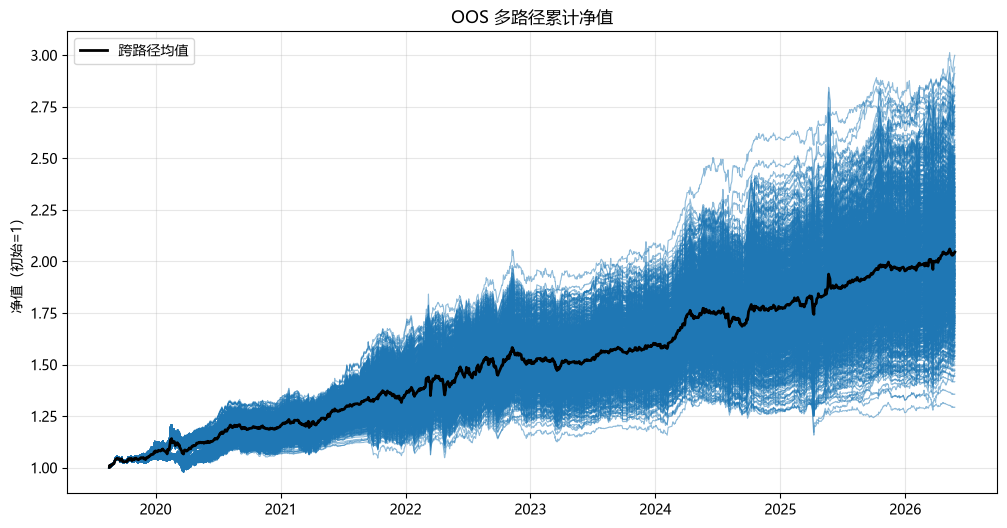

In [156]:
plot_paths_curve(oos_mpts)

In [157]:
log_print(oos_mpt.summary(),section='OSS Summary',echo=False)

### OOS诊断：
- Annualized Mean 分布
- PSR诊断
- 基准联动
- 换手频率

LHS多路径分布(1000条): 均值 0.1135 | 中位 0.1133 | 5% 0.0802 | 95% 0.1460
WF真实路径: 0.1268 | 分布中 0.65σ | 分位 72.6%


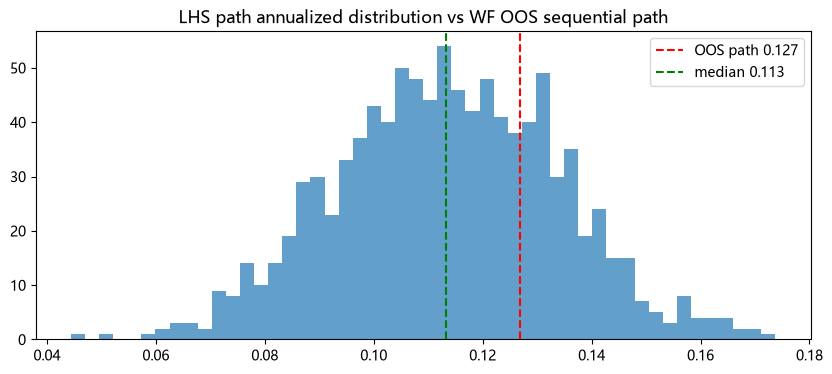

In [158]:
# 年化分布
path_anns = np.array([oos_mpt.annualized_mean for oos_mpt in oos_mpts])

oos_ann = oos_mpt.annualized_mean

report_ann_distribution(path_anns, oos_ann)

In [159]:
diagnose_result = diagnose_oos_lhs(lhs_paths=oos_paths)
del diagnose_result['mc_sharpes']
del diagnose_result['mc_mdds']
del diagnose_result['mc_psrs']
log_print(diagnose_result, section='OOS PSR Diagnose',echo=False)

[Info] 1000 LHS paths | OOS 1638 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.627, 1.295]
  ✅ MDD median / worst-5%  : 11.00% / 17.16%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.9616
  ⚠️ PSR(0) median / 5%    : 100.00% / 100.00%


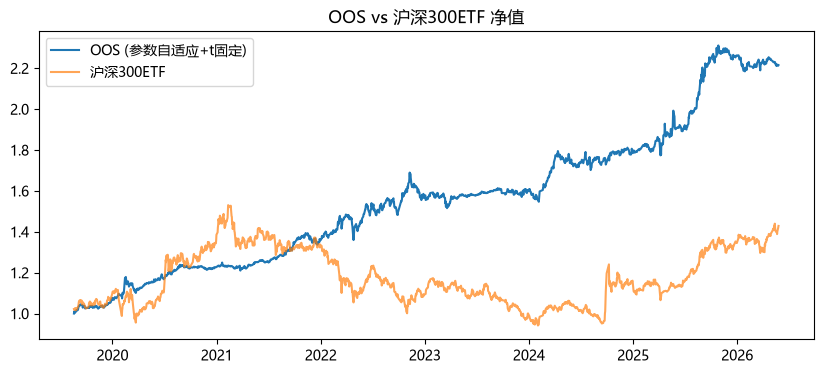

In [160]:
plot_oos_vs_bench(oos_mpt, bench_ret)

In [161]:

df_ex = excess_vs_bench(oos_mpts, bench_ret)
log_result(df_ex.describe(percentiles=[0.05, 0.5, 0.95]).loc[["5%", "50%", "95%", "mean"]].round(4),
           section="OOS vs 沪深300 相对收益分布")

      ann_excess  arith_excess      IR  winrate
5%        0.0225        0.0116  0.0726   0.5134
50%       0.0539        0.0447  0.2850   0.5256
95%       0.0848        0.0774  0.4982   0.5367
mean      0.0540        0.0449  0.2865   0.5253
